In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [119]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [120]:
cat_cols = [col for col in df.columns if df[col].dtype=='object']
cat_cols

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'TotalCharges',
 'Churn']

In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [122]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [123]:
df = df.drop(['customerID'], axis=1)

In [124]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.isnull().sum

<bound method DataFrame.sum of       gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0      False          False    False       False   False         False   
1      False          False    False       False   False         False   
2      False          False    False       False   False         False   
3      False          False    False       False   False         False   
4      False          False    False       False   False         False   
...      ...            ...      ...         ...     ...           ...   
7038   False          False    False       False   False         False   
7039   False          False    False       False   False         False   
7040   False          False    False       False   False         False   
7041   False          False    False       False   False         False   
7042   False          False    False       False   False         False   

      MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0         

In [125]:
df[np.isnan(df['TotalCharges'])]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [126]:
df = df.drop(labels=df[df['tenure']==0].index, axis=0)
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [127]:
# Feature engineering: Charges per tenure
df['ChargesPerTenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)


In [128]:
# Tenure-based churn risk buckets (bank churn inspired)
df['TenureBucket'] = pd.qcut(
    df['tenure'],
    q=5,
    labels=False
)


In [129]:
df[['tenure', 'TenureBucket']].head(10)
df['TenureBucket'].value_counts()


TenureBucket
0    1470
2    1408
4    1407
1    1397
3    1350
Name: count, dtype: int64

In [130]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

scale_cols = ['MonthlyCharges', 'TotalCharges', 'ChargesPerTenure']

df[scale_cols] = scaler.fit_transform(df[scale_cols])


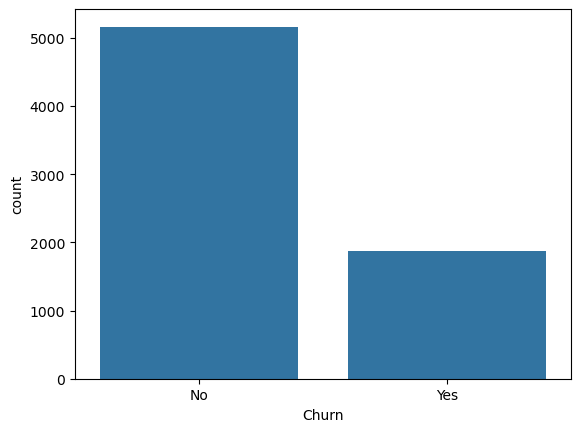

In [131]:
sns.countplot(x='Churn', data=df);

<Axes: xlabel='Churn', ylabel='count'>

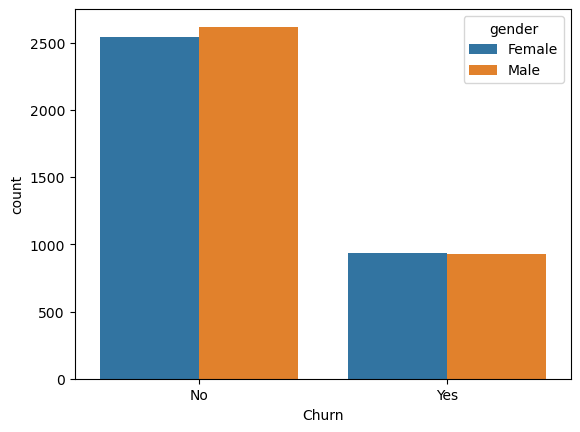

In [132]:
sns.countplot(x='Churn', hue='gender', data=df)

<Axes: xlabel='Churn', ylabel='count'>

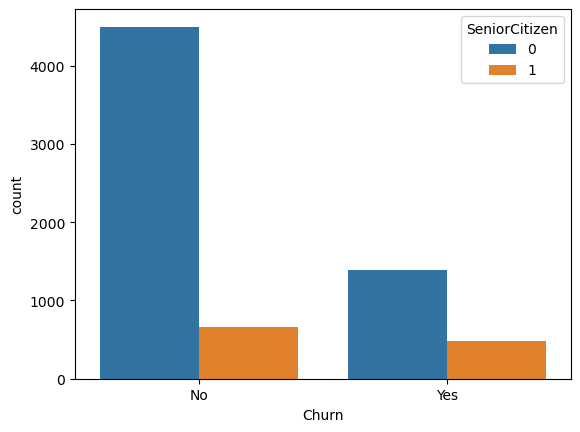

In [133]:
sns.countplot(x='Churn', hue='SeniorCitizen', data=df)

<Axes: xlabel='Churn', ylabel='count'>

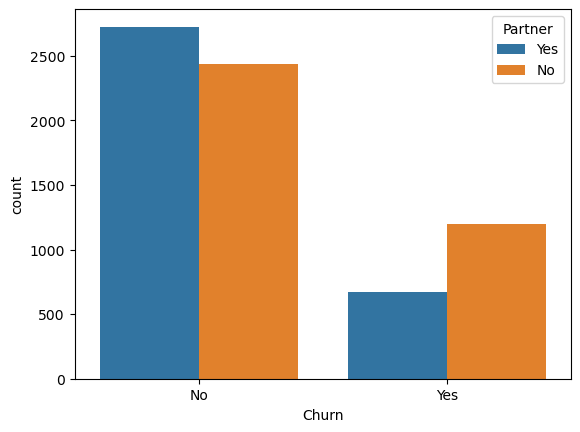

In [134]:
sns.countplot(x='Churn', hue='Partner', data=df)

<Axes: xlabel='Churn', ylabel='count'>

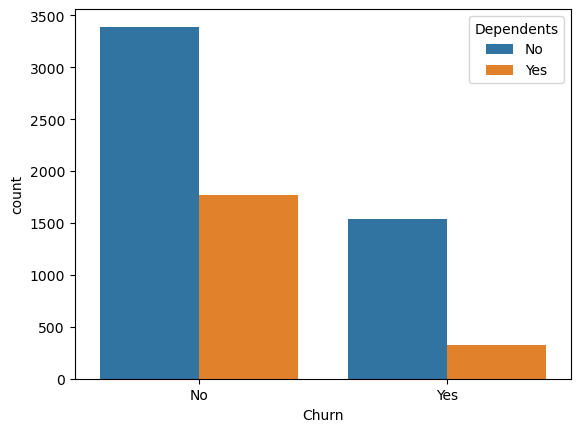

In [135]:
sns.countplot(x='Churn', hue='Dependents', data=df)

<Axes: xlabel='Churn', ylabel='count'>

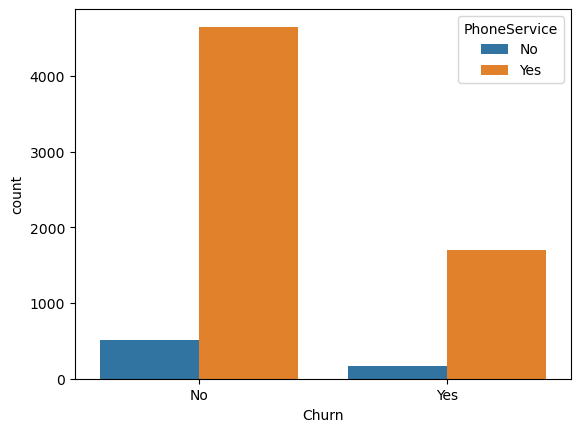

In [136]:
sns.countplot(x='Churn', hue='PhoneService', data=df)

<Axes: xlabel='Churn', ylabel='count'>

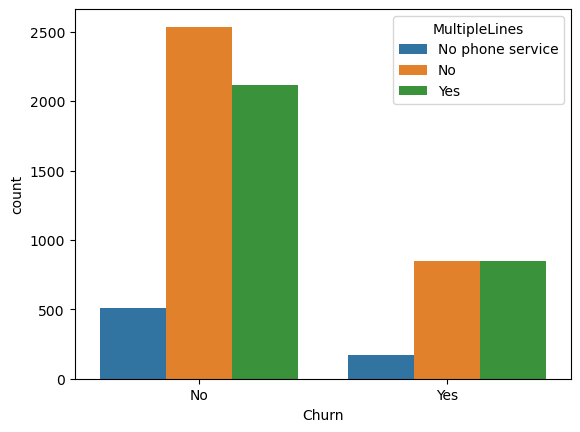

In [137]:
sns.countplot(x='Churn', hue='MultipleLines', data=df)

<Axes: xlabel='Churn', ylabel='count'>

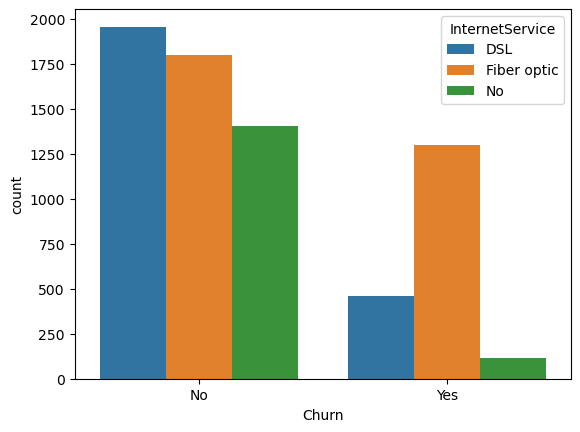

In [138]:
sns.countplot(x='Churn', hue='InternetService', data=df)

<Axes: xlabel='Churn', ylabel='count'>

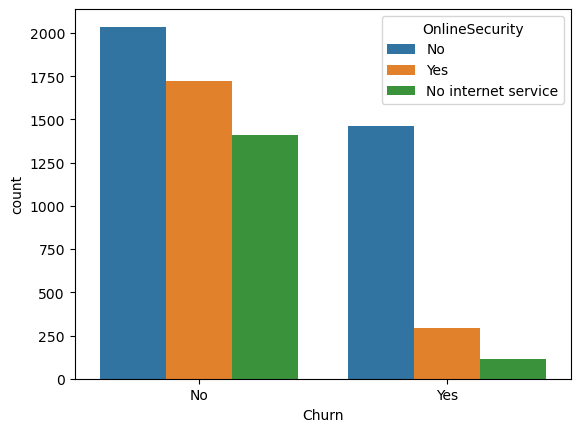

In [139]:
sns.countplot(x='Churn', hue='OnlineSecurity', data=df)

<Axes: xlabel='Churn', ylabel='count'>

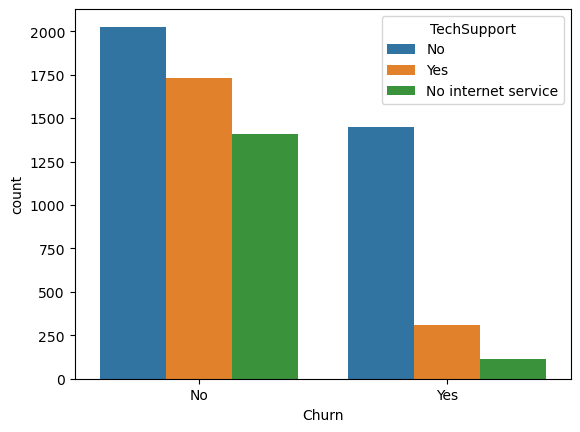

In [140]:
sns.countplot(x='Churn', hue='TechSupport', data=df)

<Axes: >

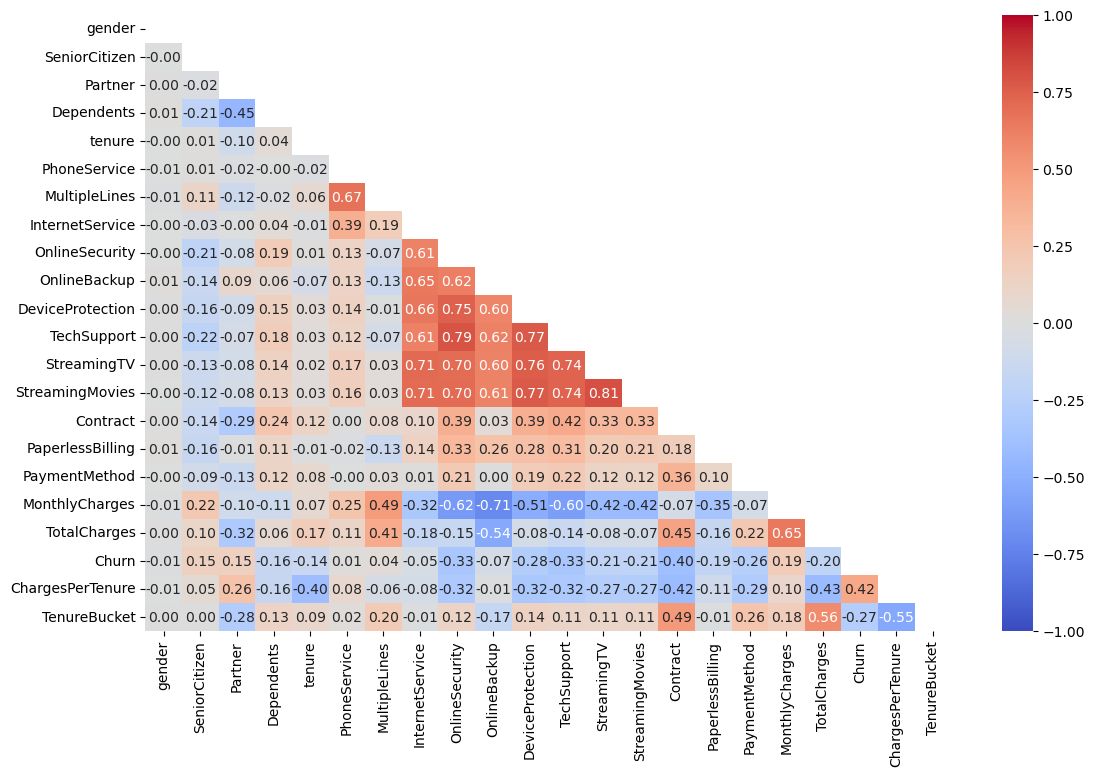

In [141]:
plt.figure(figsize=(13,8))
corr = df.apply(lambda x: pd.factorize(x)[0] if x.dtype!='float64' else x).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', vmax=1, vmin=-1, center=0, annot=True, fmt='.2f')

In [142]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

cat_cols = [col for col in df.columns if df[col].dtype == 'object' and col != 'Churn']
num_cols = [col for col in df.columns if df[col].dtype != 'object' and col != 'Churn']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)


<Axes: xlabel='TotalCharges', ylabel='Density'>

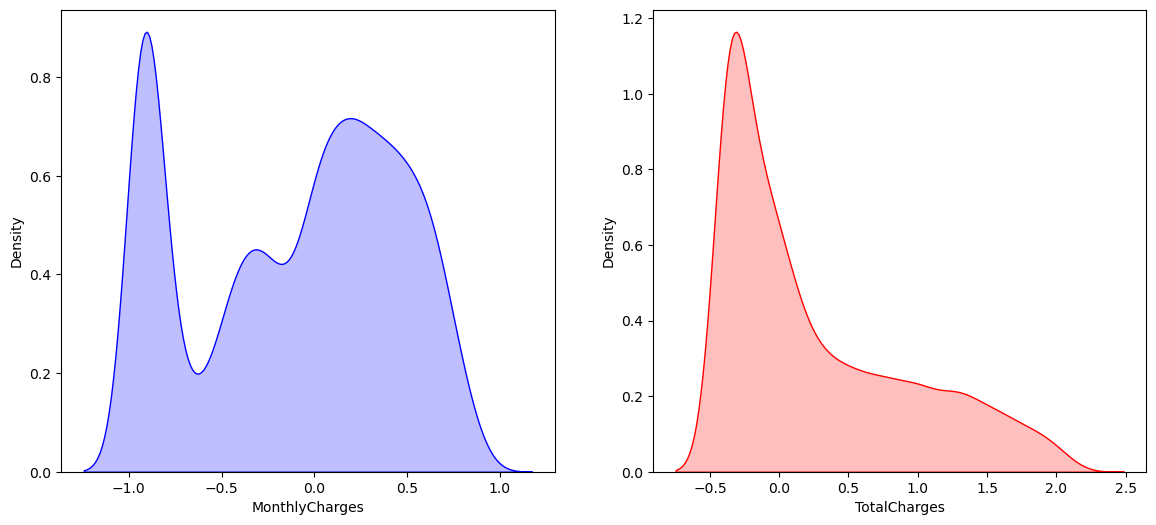

In [143]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.kdeplot(df['MonthlyCharges'], ax=axes[0], color='blue', shade=True)
sns.kdeplot(df['TotalCharges'], ax=axes[1], color='red', shade=True)

In [144]:
X = df.drop(columns=['Churn'])

# Encode target variable explicitly
y = df['Churn'].map({'No': 0, 'Yes': 1})


In [156]:
#from sklearn.model_selection import train_test_split
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
from sklearn.model_selection import train_test_split

# Step 1: Split into Train (60%) and Temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

# Step 2: Split Temp into Validation (20%) and Test (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)



In [160]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))

])
log_reg_pipeline.fit(X_train, y_train)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)
# Custom decision threshold for churn
#threshold = 0.35
y_proba = log_reg_pipeline.predict_proba(X_val)[:, 1]
from sklearn.metrics import f1_score
import numpy as np
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    f1_scores.append(f1_score(y_val, y_pred_t))

best_threshold = thresholds[np.argmax(f1_scores)]
print("Best threshold:", best_threshold)
print("Best F1:", max(f1_scores))

# FINAL evaluation on TEST set (only once)
y_test_proba = log_reg_pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_test_proba >= best_threshold).astype(int)

print("Logistic Regression Results (Churn-Focused Evaluation)")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_test_proba))


Best threshold: 0.5799999999999997
Best F1: 0.6380510440835266
Logistic Regression Results (Churn-Focused Evaluation)
              precision    recall  f1-score   support

           0       0.90      0.78      0.83      1033
           1       0.55      0.77      0.65       374

    accuracy                           0.77      1407
   macro avg       0.73      0.77      0.74      1407
weighted avg       0.81      0.77      0.78      1407

Confusion Matrix:
[[802 231]
 [ 86 288]]
ROC-AUC Score: 0.8525516252439549


In [158]:
threshold = best_threshold
y_pred = (y_proba >= threshold).astype(int)


In [161]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
from sklearn.calibration import CalibratedClassifierCV

# Extract trained Random Forest from pipeline
rf_model = rf_pipeline.named_steps['model']
# Calibrate probabilities using Platt scaling
calibrated_rf = CalibratedClassifierCV(
    estimator=rf_model,
    method='sigmoid',
    cv=5
)
# Fit calibration model on TRAIN data (important)
calibrated_rf.fit(
    rf_pipeline.named_steps['preprocessor'].transform(X_train),
    y_train
)

# ===== VALIDATION probabilities (USED ONLY for threshold tuning) =====
rf_val_proba = calibrated_rf.predict_proba(
    rf_pipeline.named_steps['preprocessor'].transform(X_val)
)[:, 1]


#rf_proba = calibrated_rf.predict_proba(
    #rf_pipeline.named_steps['preprocessor'].transform(X_test)
#)[:, 1]

#rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]
#rf_pred = rf_pipeline.predict(X_test)
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []

for t in thresholds:
    rf_pred_t = (rf_val_proba >= t).astype(int)
    f1_scores.append(f1_score(y_val, rf_pred_t))

best_threshold_rf = thresholds[np.argmax(f1_scores)]

print("Best RF threshold:", best_threshold_rf)
print("Best RF F1 (VAL):", max(f1_scores))

rf_test_proba = calibrated_rf.predict_proba(
    rf_pipeline.named_steps['preprocessor'].transform(X_test)
)[:, 1]

rf_pred = (rf_test_proba >= best_threshold_rf).astype(int)

print("Random Forest Results (FINAL TEST)")
print(classification_report(y_test, rf_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, rf_test_proba))






Best RF threshold: 0.23999999999999994
Best RF F1 (VAL): 0.6144329896907217
Random Forest Results (FINAL TEST)
              precision    recall  f1-score   support

           0       0.93      0.71      0.80      1033
           1       0.51      0.84      0.64       374

    accuracy                           0.74      1407
   macro avg       0.72      0.78      0.72      1407
weighted avg       0.82      0.74      0.76      1407

Confusion Matrix:
[[732 301]
 [ 58 316]]
ROC-AUC Score: 0.8503618555580289
